###############################################################################
# ROI VALIDATION NOTEBOOK — FINAL
#
# ═══════════════════════════════════════════════════════════════════════════
# THREE-LAYER PIPELINE
# ═══════════════════════════════════════════════════════════════════════════
#
# Layer 1 — LOCALIZE (find peak, center sphere):
#   FFA:  cope 1  (Face > Object)     — Ayzenberg 2023, Golarai 2007
#   PPA:  cope 2  (House > Object)    — Golarai 2007
#   LOC:  cope 3  (Object > Scramble) — universal standard
#   VWFA: cope 9  (Word > all others) — Nordt 2021 style; 100% selectivity
#
# Layer 2 — MEASURE (RSA, mean activation, selectivity):
#   Raw betas (copes 15-18). Independent from localization = no circularity.
#
# Layer 3 — SUPPLEMENTAL (Ayzenberg comparison):
#   cat_vs_scramble z-stats in broad masks (different ROI definition).
#
# ═══════════════════════════════════════════════════════════════════════════
# DECISION LOG
# ═══════════════════════════════════════════════════════════════════════════
#
# Localization contrast: literature_backed (copes 1, 2, 3, 9)
#   - Each contrast has clear literature precedent
#   - Face/House > Object: standard for separating from object cortex
#   - Object > Scramble: universal
#   - Word > all others: 100% selectivity in our data
#   - ACTION NEEDED: test run-pair reliability for this combination
#
# Previously tested alternatives (run-pair centroid distance, mm):
#   cat_vs_scramble (10,11,3,12):  6.20 (best uniform baseline)
#   cat_vs_all_others (6,7,8,9):   6.52
#   liu_word (10,11,3,-13):         6.64
#   original_mixed (1,2,3,12):      6.75 (worst — word>scramble weak)
#   raw_betas (15-18):              5.73 (circular with RSA)
#
# Thresholding: z > 1.96, then top 10% of suprathreshold voxels
#   - Liberal z-threshold ensures sufficient voxels survive
#   - Top 10% selects most responsive within search mask
#   - Adaptive to individual variation in activation magnitude
#
# Selectivity validation (% of ROIs selective, measured with raw betas):
#   cat_vs_all_others: face 100%, house 100%, object 100%, word 100%
#   cat_vs_scramble:   face  98%, house 100%, object 100%, word  66%
#   original_mixed:    face 100%, house  99%, object 100%, word  66%
#   liu_word:          face  98%, house 100%, object 100%, word  12%
#   raw_betas:         face  92%, house  97%, object  96%, word  26%
#

Add this to the decision log at the top:

 **Final contrast: `cat_vs_scramble` (copes 10, 11, 3, 12).** Tested five localization approaches. `cat_vs_scramble` is the only contrast that simultaneously produces the expected face rightward lateralization (d=-0.51, p=.051), significant word leftward lateralization (d=1.05, p=.010), best within-session reliability (6.20mm), and sufficient signal for robust thresholding. `cat_vs_all_others` achieves 100% word selectivity but loses face lateralization (d=-0.22, p=.464). Word univariate selectivity (66%) does not compromise the RSA pipeline, which measures multivariate pattern structure using independent raw betas. Supplemental analyses with `cat_vs_all_others` confirm word-selective regions are identifiable with an alternative contrast.


###############################################################################



In [1]:
###############################################################################
# CELL 1: Setup
###############################################################################
import os, sys, time
import numpy as np
import nibabel as nib
import pandas as pd
from pathlib import Path
from scipy.ndimage import label, center_of_mass
from scipy.stats import ttest_ind, ttest_rel, wilcoxon
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import (processed_dir, skip_subs, is_patient,
                           get_sessions, get_sub_info, _load_csv)

BASE_DIR = Path(processed_dir)
HOME_OUTPUT = Path('/home/csimmon2/roi_validation_results')
HOME_OUTPUT.mkdir(parents=True, exist_ok=True)

df = _load_csv()

print(f'Setup complete. Output: {HOME_OUTPUT}')


Setup complete. Output: /home/csimmon2/roi_validation_results


In [2]:
###############################################################################
# CELL 2: Exclusions
###############################################################################

EXCLUSION_LOG = {
    'scanner_session_drops': {
        'sub-004_ses-06': 'Voxel size 2.0mm vs 2.5mm ses-01-05. Different scanner.',
        'sub-008_ses-02': 'Voxel size 2.0mm vs ses-01 2.5mm. Scanner change.',
        'sub-018_ses-03': 'Voxel size 2.0mm vs ses-02 2.5mm. Scanner change.',
    },
    'scanner_subject_drops': {
        'sub-008': '2 sessions on different scanners. No valid longitudinal pair.',
        'sub-018': '2 sessions on different scanners. No valid longitudinal pair.',
    },
    'pre_surgery_drops': {
        'sub-021_ses-01': 'Pre-surgical', 'sub-045_ses-01': 'Pre-surgical',
        'sub-047_ses-01': 'Pre-surgical', 'sub-049_ses-01': 'Pre-surgical',
        'sub-070_ses-01': 'Pre-surgical', 'sub-073_ses-01': 'Pre-surgical',
        'sub-081_ses-01': 'Pre-surgical', 'sub-086_ses-01': 'Pre-surgical',
    },
    'age_match_drops': {
        'sub-025': 'Age matching', 'sub-027': 'Age matching',
        'sub-045': 'Age matching', 'sub-072': 'Age matching',
    },
    'other': {'OTC108': 'Excluded from original study'},
}

SCANNER_SESSION_DROPS = {'sub-004': ['06'], 'sub-008': ['02'], 'sub-018': ['03']}
SCANNER_SUBJECT_DROPS = ['sub-008', 'sub-018']
SUBJECTS_TO_SKIP = ['OTC108']

PRE_SURGERY_SESSIONS = {
    'sub-021': ['01'], 'sub-045': ['01'], 'sub-047': ['01'], 'sub-049': ['01'],
    'sub-070': ['01'], 'sub-073': ['01'], 'sub-081': ['01'], 'sub-086': ['01'],
}

exclusion_rows = []
for cat, entries in EXCLUSION_LOG.items():
    for key, reason in entries.items():
        exclusion_rows.append({'category': cat, 'id': key, 'reason': reason})
pd.DataFrame(exclusion_rows).to_csv(HOME_OUTPUT / 'exclusion_log.csv', index=False)
print('Exclusion log saved.')

Exclusion log saved.


In [3]:
###############################################################################
# CELL 3: Load Subjects
###############################################################################

def load_subjects_validated(patient_only=None):
    subjects = {}
    for sub_clean in sorted(df['sub_clean'].unique()):
        if sub_clean in skip_subs:
            continue
        subject_id = f'sub-{sub_clean}'
        if subject_id in SCANNER_SUBJECT_DROPS:
            continue
        sessions = get_sessions(sub_clean)
        if not sessions:
            continue
        if subject_id in SCANNER_SESSION_DROPS:
            sessions = [s for s in sessions
                       if f'{s:02d}' not in SCANNER_SESSION_DROPS[subject_id]]
        if not sessions:
            continue
        info = get_sub_info(sub_clean, sessions[0])
        pt = is_patient(sub_clean)
        if patient_only is True and not pt:
            continue
        if patient_only is False and pt:
            continue
        if not (BASE_DIR / subject_id).exists():
            continue
        intact = info.get('intact_hemi', '')
        hemi = ('l' if intact == 'left' else 'r') if pt else 'r'
        subjects[subject_id] = {
            'code': f"{info.get('group','')}{sub_clean}",
            'sessions': [f'{s:02d}' for s in sessions],
            'hemi': hemi,
            'group': info.get('group', 'unknown'),
            'patient_status': 'patient' if pt else 'control',
            'intact_hemi': intact
        }
    return subjects

ALL_PATIENTS = load_subjects_validated(patient_only=True)
ALL_CONTROLS = load_subjects_validated(patient_only=False)
ANALYSIS_SUBJECTS = {**ALL_PATIENTS, **ALL_CONTROLS}

print(f'Patients: {len(ALL_PATIENTS)}, Controls: {len(ALL_CONTROLS)}, '
      f'Total: {len(ANALYSIS_SUBJECTS)}')

Patients: 25, Controls: 23, Total: 48


In [21]:
###############################################################################
# CELL 4: Contrast & Category Definitions
#
# First-Level Contrast Reference:
#  1  Face>Object      6 Face>all others   10 Face>Scramble   15 Face(raw)
#  2  House>Object     7 House>all others  11 House>Scramble  16 House(raw)
#  3  Object>Scramble  8 Object>all others 12 Word>Scramble   17 Object(raw)
#  4  Word>Object      9 Word>all others   13 Face>Word       18 Word(raw)
#  5  Scramble>Avg    14 Object>House                         19 Scramble(raw)
###############################################################################

# ── PRIMARY: Literature-backed localization ──
#PIPELINE_CONTRAST = {
#    'name': 'literature_backed',
#    'description': 'FFA:Face>Obj, PPA:House>Obj, LOC:Obj>Scram, VWFA:Word>allOthers',
#    'copes': {'face': 1, 'house': 2, 'object': 3, 'word': 9},
#}

PIPELINE_CONTRAST = {
    'name': 'cat_vs_scramble',
    'description': 'Category > Scrambled (consistent baseline)',
    'copes': {'face': 10, 'house': 11, 'object': 3, 'word': 12},
}

# ── All tested candidates ──
CONTRAST_CANDIDATES = {
    'literature_backed': {
        'description': 'Face>Obj, House>Obj, Obj>Scram, Word>allOthers',
        'copes': {'face': 1, 'house': 2, 'object': 3, 'word': 9},
    },
    'cat_vs_scramble': {
        'description': 'Category > Scrambled (consistent baseline)',
        'copes': {'face': 10, 'house': 11, 'object': 3, 'word': 12},
    },
    'cat_vs_all_others': {
        'description': 'Category > mean(all others + scrambled)',
        'copes': {'face': 6, 'house': 7, 'object': 8, 'word': 9},
    },
    'original_mixed': {
        'description': 'Original (inconsistent baselines)',
        'copes': {'face': 1, 'house': 2, 'object': 3, 'word': 12},
    },
    'raw_betas': {
        'description': 'Raw betas (circular with RSA)',
        'copes': {'face': 15, 'house': 16, 'object': 17, 'word': 18},
    },
}

# ── Measurement: raw betas (independent from localization) ──
RSA_COPE_MAP = {'face': 15, 'house': 16, 'object': 17, 'word': 18}

CATEGORIES = ['face', 'house', 'object', 'word']
BILATERAL_CATEGORIES = ['object', 'house']
PREFERRED_HEMI = {'Face': 'r', 'Word': 'l', 'House': 'both', 'Object': 'both'}

print(f'Pipeline: {PIPELINE_CONTRAST["name"]}')
print(f'  {PIPELINE_CONTRAST["description"]}')
print(f'  Copes: {PIPELINE_CONTRAST["copes"]}')
print(f'RSA betas: {RSA_COPE_MAP}')

Pipeline: cat_vs_scramble
  Category > Scrambled (consistent baseline)
  Copes: {'face': 10, 'house': 11, 'object': 3, 'word': 12}
RSA betas: {'face': 15, 'house': 16, 'object': 17, 'word': 18}


In [31]:

###############################################################################
# CELL 5: NIfTI Cache & Core ROI Extraction
###############################################################################

_NIFTI_CACHE = {}

def _load_nifti_cached(filepath):
    key = str(filepath)
    if key not in _NIFTI_CACHE:
        _NIFTI_CACHE[key] = nib.load(key)
    return _NIFTI_CACHE[key]

def clear_nifti_cache():
    global _NIFTI_CACHE
    n = len(_NIFTI_CACHE)
    _NIFTI_CACHE = {}
    print(f'Cleared {n} cached files')


def extract_peak_and_cluster(subject_id, session, category, hemi,
                             cope_num, threshold_z=1.96, top_pct=0.10,
                             min_voxels=50, contrast_sign=1):
    """
    1. Threshold at z > threshold_z within search mask
    2. Take top top_pct% of suprathreshold voxels
    3. Find largest cluster, extract peak and centroid
    """
    info = ANALYSIS_SUBJECTS[subject_id]
    first_session = info['sessions'][0]

    brain_mask_file = (BASE_DIR / subject_id / f'ses-{first_session}' /
                       'anat' / 'T1w_brain_mask.nii.gz')
    brain_mask = (_load_nifti_cached(brain_mask_file).get_fdata() > 0
                  if brain_mask_file.exists() else None)

    mask_file = None
    for subdir in ['ROIs', os.path.join('derivatives', 'rois')]:
        p = (BASE_DIR / subject_id / f'ses-{first_session}' / subdir /
             f'{hemi}_{category}_searchmask.nii.gz')
        if p.exists():
            mask_file = p
            break
    if mask_file is None:
        return None

    mask_img = _load_nifti_cached(mask_file)
    mask = mask_img.get_fdata() > 0
    affine = mask_img.affine

    feat_dir = (BASE_DIR / subject_id / f'ses-{session}' /
                'derivatives' / 'fsl' / 'loc' / 'HighLevel.gfeat')
    zstat_name = ('zstat1.nii.gz' if session == first_session
                  else f'zstat1_ses{first_session}.nii.gz')
    zstat_file = feat_dir / f'cope{cope_num}.feat' / 'stats' / zstat_name

    if not zstat_file.exists():
        return None

    zstat = _load_nifti_cached(zstat_file).get_fdata().copy()
    zstat = zstat * contrast_sign
    if brain_mask is not None:
        zstat[~brain_mask] = 0

    suprathresh = (zstat > threshold_z) & mask
    n_suprathresh = suprathresh.sum()
    if n_suprathresh < min_voxels:
        return None

    top_n = max(min_voxels, int(n_suprathresh * top_pct))
    top_n = min(top_n, n_suprathresh)
    suprathresh_vals = zstat[suprathresh]
    top_threshold = np.sort(suprathresh_vals)[-top_n]
    top_mask = (zstat >= top_threshold) & suprathresh

    labeled, n_clusters = label(top_mask)
    if n_clusters == 0:
        return None

    cluster_sizes = [(labeled == i).sum() for i in range(1, n_clusters + 1)]
    largest_idx = np.argmax(cluster_sizes) + 1
    roi_mask = (labeled == largest_idx)

    peak_idx = np.unravel_index(np.argmax(zstat * roi_mask), zstat.shape)

    return {
        'n_voxels': cluster_sizes[largest_idx - 1],
        'n_suprathresh': n_suprathresh,
        'peak_z': zstat[peak_idx],
        'mean_z': np.mean(zstat[roi_mask]),
        'peak_coord': nib.affines.apply_affine(affine, np.array(peak_idx)),
        'centroid': nib.affines.apply_affine(affine, np.array(center_of_mass(roi_mask))),
        'roi_mask': roi_mask,
    }

print('Extraction functions defined.')


Extraction functions defined.


In [32]:
###############################################################################
# CELL 6: Ayzenberg Metrics — Mean Act, Selectivity, Volume
#          (both hemispheres, all groups, post-surgery only)
###############################################################################

def compute_ayzenberg_metrics():
    """
    Localize with PIPELINE_CONTRAST, measure with raw betas (RSA_COPE_MAP).
    Post-surgical sessions only. Both hemispheres for all subjects.
    """
    print('\nAYZENBERG METRICS')
    print('=' * 70)
    print(f'Localization: {PIPELINE_CONTRAST["name"]} (z>1.96, top 10%)')
    print(f'Measurement: raw betas (copes 15-18)')

    roi_copes = PIPELINE_CONTRAST['copes']
    rows = []

    for subject_id, info in ANALYSIS_SUBJECTS.items():
        first_session = info['sessions'][0]

        for session in info['sessions']:
            if subject_id in PRE_SURGERY_SESSIONS and \
               session in PRE_SURGERY_SESSIONS[subject_id]:
                continue

            feat_dir = (BASE_DIR / subject_id / f'ses-{session}' /
                        'derivatives' / 'fsl' / 'loc' / 'HighLevel.gfeat')
            # For raw betas, use cope files not zstat
            cope_name = ('cope1.nii.gz' if session == first_session
                         else f'cope1_ses{first_session}.nii.gz')

            for hemi in ['l', 'r']:
                for category in CATEGORIES:
                    roi = extract_peak_and_cluster(
                        subject_id, session, category, hemi,
                        roi_copes[category])
                    if roi is None:
                        continue

                    roi_mask = roi['roi_mask']

                    # Voxel volume
                    mask_file = None
                    for subdir in ['ROIs', os.path.join('derivatives', 'rois')]:
                        p = (BASE_DIR / subject_id / f'ses-{first_session}' /
                             subdir / f'{hemi}_{category}_searchmask.nii.gz')
                        if p.exists():
                            mask_file = p
                            break
                    if mask_file is None:
                        continue
                    voxel_vol = float(np.prod(
                        nib.load(str(mask_file)).header.get_zooms()[:3]))

                    # Measure activation with RAW BETAS
                    activations = {}
                    for mcat, mcope in RSA_COPE_MAP.items():
                        cope_file = (feat_dir / f'cope{mcope}.feat' / 'stats' /
                                     cope_name)
                        if cope_file.exists():
                            activations[mcat] = _load_nifti_cached(
                                cope_file).get_fdata()[roi_mask]

                    if len(activations) < 4:
                        continue

                    pref = activations[category]
                    nonpref_stack = np.column_stack(
                        [activations[c] for c in CATEGORIES if c != category])
                    sel_per_voxel = pref - np.mean(nonpref_stack, axis=1)

                    if info['patient_status'] == 'patient':
                        intact = info['intact_hemi']
                        hemi_label = ('Intact' if (hemi == 'l' and intact == 'left') or
                                      (hemi == 'r' and intact == 'right') else 'Lesioned')
                    else:
                        hemi_label = 'Left' if hemi == 'l' else 'Right'

                    rows.append({
                        'subject': info['code'],
                        'group': (info['group'] if info['patient_status'] == 'patient'
                                 else 'control'),
                        'status': info['patient_status'],
                        'session': session, 'hemi': hemi,
                        'hemi_label': hemi_label, 'category': category,
                        'mean_act': np.mean(pref),
                        'sum_selec_norm': np.mean(sel_per_voxel),
                        'volume_mm3': roi['n_voxels'] * voxel_vol,
                        'n_voxels': roi['n_voxels'],
                        'peak_z': roi['peak_z'],
                    })

    ayz_df = pd.DataFrame(rows)
    print(f'Computed: {len(ayz_df)} ROIs, {ayz_df["subject"].nunique()} subjects')
    for grp in ['OTC', 'nonOTC', 'control']:
        gd = ayz_df[ayz_df['group'] == grp]
        print(f'  {grp}: {gd["subject"].nunique()} subjects, {len(gd)} ROIs')
    return ayz_df


ayz_df = compute_ayzenberg_metrics()
ayz_df.to_csv(HOME_OUTPUT / 'ayzenberg_metrics.csv', index=False)
clear_nifti_cache()


AYZENBERG METRICS
Localization: cat_vs_scramble (z>1.96, top 10%)
Measurement: raw betas (copes 15-18)
Computed: 459 ROIs, 40 subjects
  OTC: 13 subjects, 151 ROIs
  nonOTC: 9 subjects, 97 ROIs
  control: 18 subjects, 211 ROIs
Cleared 921 cached files


In [33]:
###############################################################################
# CELL 7: Subject Counts
###############################################################################

def print_counts(ayz_df):
    avg = ayz_df.groupby(
        ['subject', 'group', 'status', 'hemi', 'category']
    ).first().reset_index()

    print('SUBJECT COUNTS')
    print('=' * 70)
    print(f"{'Group':<12} {'Hemi':<6} {'Face':<8} {'House':<8} {'Object':<8} {'Word'}")
    print('-' * 50)

    for grp in ['control', 'OTC', 'nonOTC']:
        for hemi in ['l', 'r']:
            if grp == 'control':
                gd = avg[(avg['status'] == 'control') & (avg['hemi'] == hemi)]
            else:
                gd = avg[(avg['group'] == grp) & (avg['hemi'] == hemi)]
            counts = {cat: gd[gd['category'] == cat]['subject'].nunique()
                     for cat in CATEGORIES}
            label = f"{grp} {'L' if hemi == 'l' else 'R'}"
            print(f"{label:<12} {hemi:<6} {counts['face']:<8} {counts['house']:<8} "
                  f"{counts['object']:<8} {counts['word']}")

    print(f"\nTOTAL unique subjects:")
    for grp in ['control', 'OTC', 'nonOTC']:
        gd = avg[avg['group'] == grp] if grp != 'control' else avg[avg['status'] == 'control']
        print(f"  {grp}: {gd['subject'].nunique()}")

print_counts(ayz_df)

SUBJECT COUNTS
Group        Hemi   Face     House    Object   Word
--------------------------------------------------
control L    l      17       18       18       17
control R    r      17       18       18       17
OTC L        l      10       13       12       11
OTC R        r      12       13       12       12
nonOTC L     l      8        9        9        9
nonOTC R     r      8        9        9        8

TOTAL unique subjects:
  control: 18
  OTC: 13
  nonOTC: 9


In [34]:
###############################################################################
# CELL 8: Hemispheric Lateralization — Controls
###############################################################################

def test_lateralization(ayz_df):
    print('\nHEMISPHERIC LATERALIZATION — CONTROLS')
    print('=' * 70)
    print('Expected: Face->Right, Word->Left, House/Object->Bilateral\n')

    ctrl = ayz_df[ayz_df['status'] == 'control'].copy()
    ctrl_avg = ctrl.groupby(['subject', 'hemi', 'category']).agg({
        'mean_act': 'mean', 'sum_selec_norm': 'mean', 'volume_mm3': 'mean'
    }).reset_index()

    for metric, name in [('sum_selec_norm', 'Summed Selectivity'),
                          ('mean_act', 'Mean Activation'),
                          ('volume_mm3', 'Active Volume')]:
        print(f'\n{name}:')
        print(f"{'Cat':<10} {'Left':<10} {'Right':<10} {'t':<8} {'df':<5} "
              f"{'p':<10} {'d':<8} {'Dir'}")
        print('-' * 70)

        for cat in CATEGORIES:
            wide = ctrl_avg[ctrl_avg['category'] == cat].pivot(
                index='subject', columns='hemi', values=metric).dropna()
            if len(wide) < 3 or 'l' not in wide.columns or 'r' not in wide.columns:
                continue
            lv, rv = wide['l'].values, wide['r'].values
            t, p = ttest_rel(lv, rv)
            d = (lv.mean() - rv.mean()) / np.sqrt((lv.std()**2 + rv.std()**2) / 2)
            sig = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else ''
            direction = 'L>R' if lv.mean() > rv.mean() else 'R>L'
            print(f"{cat:<10} {lv.mean():<10.3f} {rv.mean():<10.3f} "
                  f"{t:<8.3f} {len(wide)-1:<5} {p:<10.4f} {d:<8.3f} "
                  f"{direction} {sig}")

test_lateralization(ayz_df)


HEMISPHERIC LATERALIZATION — CONTROLS
Expected: Face->Right, Word->Left, House/Object->Bilateral


Summed Selectivity:
Cat        Left       Right      t        df    p          d        Dir
----------------------------------------------------------------------
face       71.926     87.224     -1.490   16    0.1556     -0.426   R>L 
house      109.303    113.846    -0.704   17    0.4912     -0.133   R>L 
object     76.511     57.344     2.801    17    0.0123     0.715    L>R *
word       35.028     2.768      2.533    16    0.0222     1.002    L>R *

Mean Activation:
Cat        Left       Right      t        df    p          d        Dir
----------------------------------------------------------------------
face       128.525    137.071    -0.674   16    0.5100     -0.155   R>L 
house      76.872     80.253     -0.326   17    0.7485     -0.072   R>L 
object     143.779    130.190    1.904    17    0.0740     0.295    L>R 
word       99.516     48.227     4.288    16    0.0006     1.31

In [26]:
###############################################################################
# CELL 9: Statistical Models
###############################################################################

def run_group_models(ayz_df):
    """OLS: metric ~ C(group) + age, per category. Intact hemi for patients."""
    print('\nGROUP COMPARISONS — OLS WITH AGE COVARIATE')
    print('=' * 70)
    print('Model: metric ~ C(group, Treatment("control")) + age\n')

    avg = ayz_df.groupby(
        ['subject', 'group', 'status', 'hemi', 'hemi_label', 'category']
    ).agg({'mean_act': 'mean', 'sum_selec_norm': 'mean',
           'volume_mm3': 'mean'}).reset_index()

    ctrl = avg[avg['status'] == 'control'].copy()
    ctrl_pref = ctrl[ctrl.apply(
        lambda r: PREFERRED_HEMI[r['category'].title()] in ('both', r['hemi']),
        axis=1)]
    ctrl_final = ctrl_pref.groupby(['subject', 'category']).agg(
        {'mean_act': 'mean', 'sum_selec_norm': 'mean', 'volume_mm3': 'mean'}
    ).reset_index()
    ctrl_final['group'] = 'control'

    otc = avg[(avg['group'] == 'OTC') & (avg['hemi_label'] == 'Intact')].copy()
    nonotc = avg[(avg['group'] == 'nonOTC') & (avg['hemi_label'] == 'Intact')].copy()

    age_map = {}
    for sid, info in ANALYSIS_SUBJECTS.items():
        sub_clean = sid.replace('sub-', '')
        sub_rows = df[df['sub_clean'] == sub_clean]
        if len(sub_rows) > 0:
            age_map[info['code']] = sub_rows.iloc[0]['age']

    model_frames = []
    for cat in CATEGORIES:
        for source, gl in [(ctrl_final, 'control'), (otc, 'OTC'), (nonotc, 'nonOTC')]:
            cd = source[source['category'] == cat].copy()
            cd['group'] = gl
            cd['category'] = cat
            cd['age'] = cd['subject'].map(age_map)
            model_frames.append(cd[['subject', 'group', 'category', 'age',
                                    'mean_act', 'sum_selec_norm', 'volume_mm3']])

    model_df = pd.concat(model_frames, ignore_index=True).dropna(subset=['age'])
    sig_results = {}

    for metric, name in [('sum_selec_norm', 'Summed Selectivity'),
                          ('mean_act', 'Mean Activation'),
                          ('volume_mm3', 'Active Volume')]:
        print(f'\n{name}:')
        sig_results[metric] = {}
        for cat in CATEGORIES:
            cat_df = model_df[model_df['category'] == cat]
            for pt_grp in ['OTC', 'nonOTC']:
                subset = cat_df[cat_df['group'].isin([pt_grp, 'control'])].copy()
                if len(subset[subset['group'] == pt_grp]) < 2:
                    continue
                formula = f'{metric} ~ C(group, Treatment("control")) + age'
                try:
                    model = smf.ols(formula, data=subset).fit()
                    gk = [k for k in model.params.index if pt_grp in k][0]
                    coef = model.params[gk]
                    pval = model.pvalues[gk]
                    age_p = model.pvalues['age']
                    sig_results[metric][(cat, pt_grp)] = pval
                    print(f'  {cat} {pt_grp} vs Ctrl: coef={coef:.3f} p={pval:.4f} '
                          f'| age p={age_p:.4f} | R2={model.rsquared:.3f}')
                except Exception as e:
                    print(f'  {cat} {pt_grp}: failed ({e})')

    return sig_results


def run_hemi_tests(ayz_df):
    """Within-group hemispheric: Wilcoxon signed-rank."""
    print('\nWITHIN-GROUP HEMISPHERIC TESTS (Wilcoxon)')
    print('=' * 70)

    avg = ayz_df.groupby(
        ['subject', 'group', 'status', 'hemi', 'category']
    ).agg({'mean_act': 'mean', 'sum_selec_norm': 'mean',
           'volume_mm3': 'mean'}).reset_index()

    hemi_sig = {}
    for metric, name in [('sum_selec_norm', 'Summed Selectivity'),
                          ('mean_act', 'Mean Activation'),
                          ('volume_mm3', 'Active Volume')]:
        print(f'\n{name}:')
        print(f"{'Group':<12} {'Cat':<10} {'L':<10} {'R':<10} "
              f"{'N':<6} {'W':<8} {'p':<10} {'Dir'}")
        print('-' * 72)
        hemi_sig[metric] = {}

        for grp in ['control', 'OTC', 'nonOTC']:
            for cat in CATEGORIES:
                gd = avg[((avg['status'] == 'control') if grp == 'control'
                          else (avg['group'] == grp)) &
                         (avg['category'] == cat)]
                wide = gd.pivot(index='subject', columns='hemi',
                               values=metric).dropna()
                if len(wide) < 3 or 'l' not in wide.columns or 'r' not in wide.columns:
                    continue
                lv, rv = wide['l'].values, wide['r'].values
                if np.all(lv - rv == 0):
                    continue
                try:
                    w, p = wilcoxon(lv, rv)
                except ValueError:
                    continue
                direction = 'L>R' if np.mean(lv) > np.mean(rv) else 'R>L'
                sig = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else ''
                print(f"{grp:<12} {cat:<10} {np.mean(lv):<10.2f} {np.mean(rv):<10.2f} "
                      f"{len(wide):<6} {w:<8.0f} {p:<10.4f} {direction} {sig}")
                hemi_sig[metric][(grp, cat)] = {'p': p, 'direction': direction}

    return hemi_sig


sig_results = run_group_models(ayz_df)
hemi_sig = run_hemi_tests(ayz_df)


GROUP COMPARISONS — OLS WITH AGE COVARIATE
Model: metric ~ C(group, Treatment("control")) + age


Summed Selectivity:
  face OTC vs Ctrl: coef=-12.326 p=0.4000 | age p=0.0682 | R2=0.135
  face nonOTC vs Ctrl: coef=20.342 p=0.3338 | age p=0.0755 | R2=0.184
  house OTC vs Ctrl: coef=-26.652 p=0.0722 | age p=0.1680 | R2=0.164
  house nonOTC vs Ctrl: coef=-3.947 p=0.7967 | age p=0.5233 | R2=0.019
  object OTC vs Ctrl: coef=9.973 p=0.4526 | age p=0.0975 | R2=0.111
  object nonOTC vs Ctrl: coef=1.180 p=0.9138 | age p=0.4363 | R2=0.026
  word OTC vs Ctrl: coef=-3.983 p=0.8041 | age p=0.1706 | R2=0.075
  word nonOTC vs Ctrl: coef=-10.907 p=0.4554 | age p=0.4572 | R2=0.054

Mean Activation:
  face OTC vs Ctrl: coef=-27.887 p=0.2163 | age p=0.0357 | R2=0.188
  face nonOTC vs Ctrl: coef=10.721 p=0.7264 | age p=0.1321 | R2=0.111
  house OTC vs Ctrl: coef=1.545 p=0.9277 | age p=0.2715 | R2=0.043
  house nonOTC vs Ctrl: coef=29.176 p=0.2477 | age p=0.4557 | R2=0.081
  object OTC vs Ctrl: coef=2.136

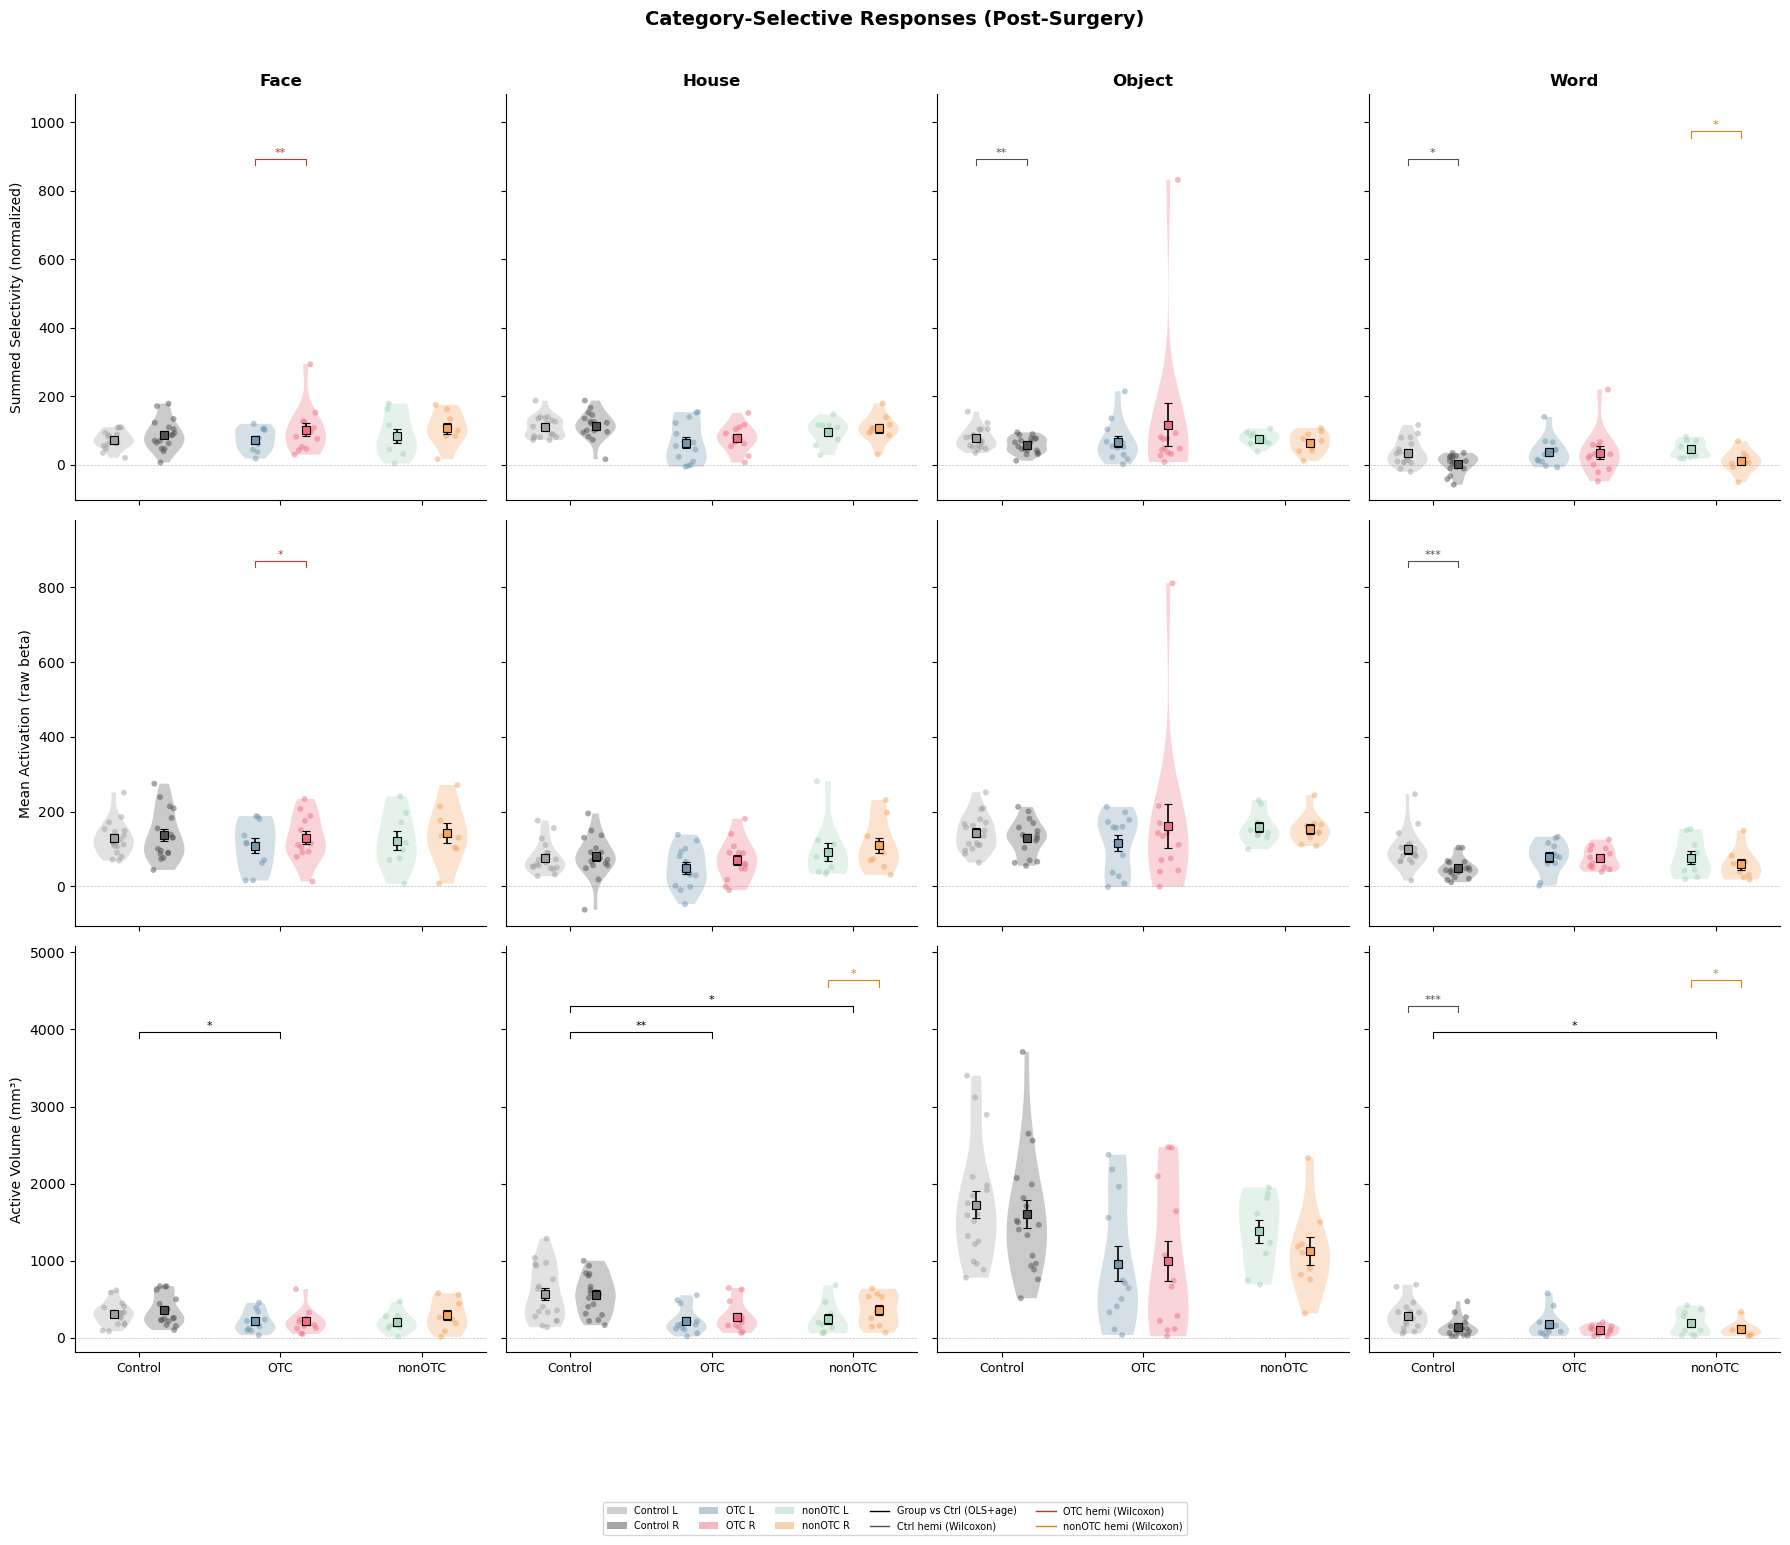

Saved: ayzenberg_shared_scale.png


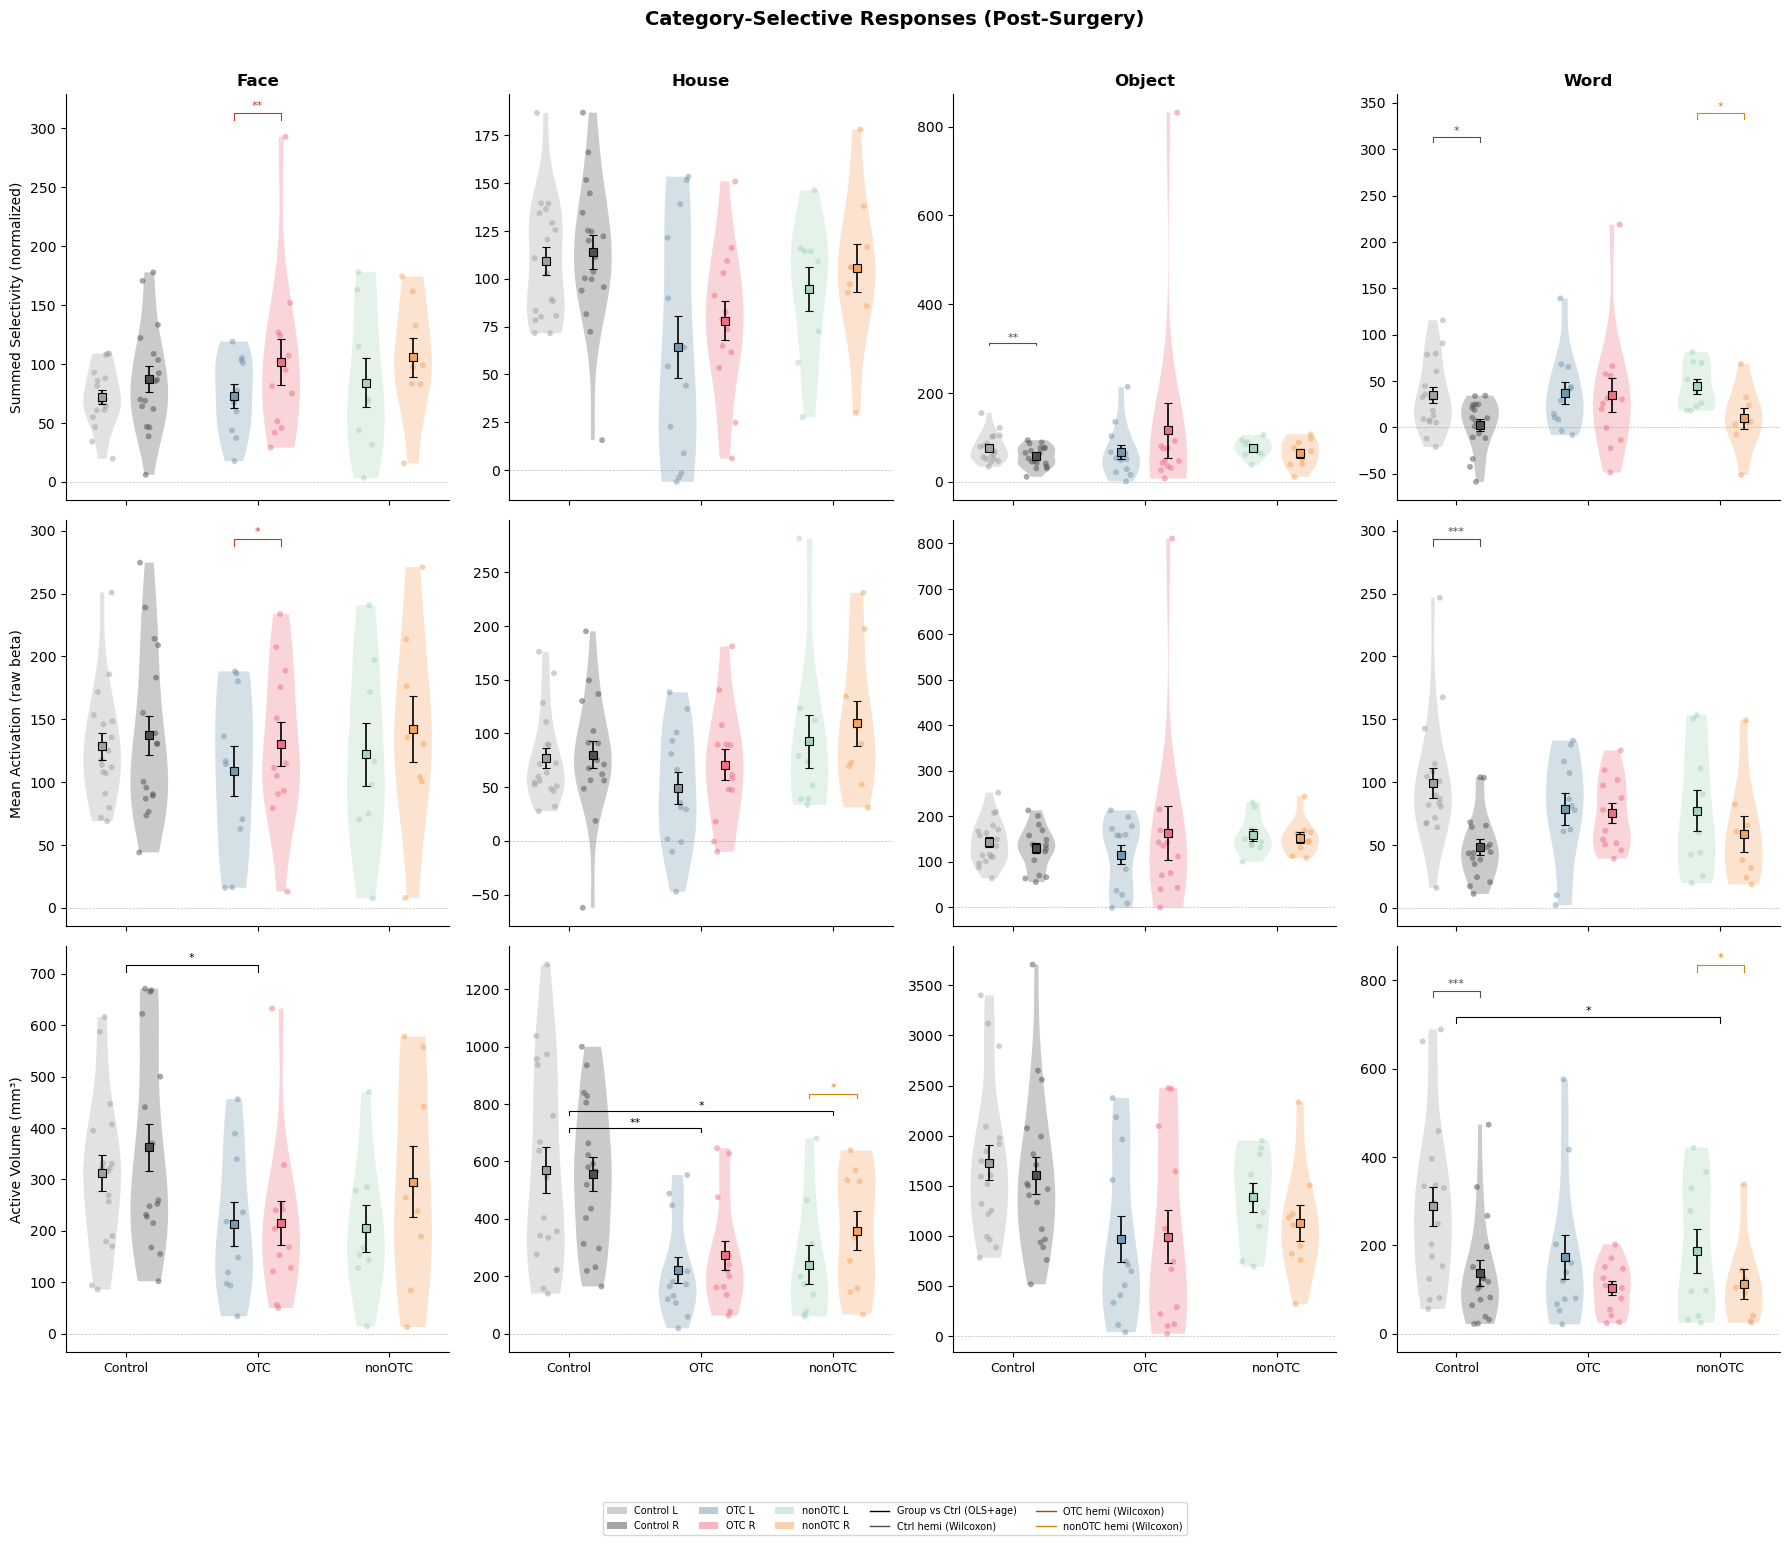

Saved: ayzenberg_independent_scale.png


In [27]:
###############################################################################
# CELL 10: Violin Plot — All Groups (shared y-axis within metric)
###############################################################################

def add_sig_bracket(ax, x1, x2, y, p, color='black'):
    if p >= 0.05:
        return
    sig = '***' if p < .001 else '**' if p < .01 else '*'
    ax.plot([x1, x1, x2, x2], [y, y*1.02, y*1.02, y], color=color, linewidth=0.8)
    ax.text((x1+x2)/2, y*1.03, sig, ha='center', fontsize=8, color=color)


def plot_main(ayz_df, sig_results, hemi_sig, shared_y=True):
    """
    All three groups, L/R split, with significance brackets.
    Controls gray, OTC blue/pink, nonOTC green/orange.
    """
    metrics = [
        ('sum_selec_norm', 'Summed Selectivity (normalized)'),
        ('mean_act', 'Mean Activation (raw beta)'),
        ('volume_mm3', 'Active Volume (mm\u00b3)')
    ]

    avg = ayz_df.groupby(
        ['subject', 'group', 'status', 'hemi', 'hemi_label', 'category']
    ).agg({m[0]: 'mean' for m in metrics}).reset_index()

    slot_colors = {
        ('control', 'Left'):  '#a0a0a0', ('control', 'Right'): '#505050',
        ('OTC', 'Left'):      '#7398af', ('OTC', 'Right'):     '#ee7183',
        ('nonOTC', 'Left'):   '#a8d5ba', ('nonOTC', 'Right'):  '#f4a460',
    }

    plot_slots = [
        ('control', 'Left',  0.0),  ('control', 'Right', 0.5),
        ('OTC',     'Left',  1.4),  ('OTC',     'Right', 1.9),
        ('nonOTC',  'Left',  2.8),  ('nonOTC',  'Right', 3.3),
    ]

    fig, axes = plt.subplots(len(metrics), len(CATEGORIES),
                             figsize=(4.5 * len(CATEGORIES), 5 * len(metrics)),
                             sharey='row' if shared_y else False)
    rng = np.random.default_rng(2)

    # PASS 1: data
    for row_idx, (metric, ylabel) in enumerate(metrics):
        for col_idx, cat in enumerate(CATEGORIES):
            ax = axes[row_idx, col_idx]
            cat_data = avg[avg['category'] == cat]
            vd, vp, vc = [], [], []

            for grp, hemi_lbl, pos in plot_slots:
                color = slot_colors[(grp, hemi_lbl)]
                if grp == 'control':
                    gd = cat_data[(cat_data['status'] == 'control') &
                                  (cat_data['hemi_label'] == hemi_lbl)][metric].values
                else:
                    gd = cat_data[(cat_data['group'] == grp) &
                                  (cat_data['hemi'] == ('l' if hemi_lbl == 'Left' else 'r'))][metric].values

                if len(gd) < 2:
                    if len(gd) > 0:
                        ax.scatter([pos], gd, color=color, alpha=0.6, s=20, zorder=3, edgecolors='none')
                    continue

                vd.append(gd); vp.append(pos); vc.append(color)

                jitter = rng.uniform(-0.12, 0.12, len(gd))
                ax.scatter(np.full(len(gd), pos) + jitter, gd,
                          color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
                ax.errorbar(pos, np.mean(gd), yerr=np.std(gd)/np.sqrt(len(gd)),
                           color='black', marker='s', markersize=6,
                           markerfacecolor=color, markeredgecolor='black',
                           markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

            if vd:
                vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                                      showmedians=False, showextrema=False, widths=0.4)
                for i, body in enumerate(vplot['bodies']):
                    body.set_facecolor(vc[i]); body.set_alpha(0.3); body.set_edgecolor('none')

            ax.set_xticks([0.25, 1.65, 3.05])
            ax.set_xticklabels(['Control', 'OTC', 'nonOTC'] if row_idx == len(metrics)-1 else [],
                               fontsize=9)
            if col_idx == 0:
                ax.set_ylabel(ylabel, fontsize=10)
            if row_idx == 0:
                ax.set_title(cat.title(), fontsize=12, fontweight='bold')
            ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

    # PASS 2: brackets (after y-axes settled)
    for row_idx, (metric, ylabel) in enumerate(metrics):
        ymin, ymax = axes[row_idx, 0].get_ylim()
        y_range = ymax - ymin
        max_bracket = ymax

        for col_idx, cat in enumerate(CATEGORIES):
            ax = axes[row_idx, col_idx]
            by = ymax

            if sig_results and metric in sig_results:
                for pt_grp, bx in [('OTC', (0.25, 1.65)), ('nonOTC', (0.25, 3.05))]:
                    p = sig_results[metric].get((cat, pt_grp), 1.0)
                    if p < 0.05:
                        add_sig_bracket(ax, bx[0], bx[1], by, p, 'black')
                        by += y_range * 0.08

            if hemi_sig and metric in hemi_sig:
                for grp, bx, clr in [('control', (0.0, 0.5), '#505050'),
                                      ('OTC', (1.4, 1.9), '#c0392b'),
                                      ('nonOTC', (2.8, 3.3), '#d4850a')]:
                    p = hemi_sig[metric].get((grp, cat), {}).get('p', 1.0)
                    if p < 0.05:
                        add_sig_bracket(ax, bx[0], bx[1], by, p, clr)
                        by += y_range * 0.08

            max_bracket = max(max_bracket, by)

        if shared_y:
            for ci in range(len(CATEGORIES)):
                axes[row_idx, ci].set_ylim(ymin, max_bracket + y_range * 0.05)

    # Legend
    legend_elements = [
        Patch(facecolor='#a0a0a0', alpha=0.5, label='Control L'),
        Patch(facecolor='#505050', alpha=0.5, label='Control R'),
        Patch(facecolor='#7398af', alpha=0.5, label='OTC L'),
        Patch(facecolor='#ee7183', alpha=0.5, label='OTC R'),
        Patch(facecolor='#a8d5ba', alpha=0.5, label='nonOTC L'),
        Patch(facecolor='#f4a460', alpha=0.5, label='nonOTC R'),
        Line2D([0], [0], color='black', lw=1, label='Group vs Ctrl (OLS+age)'),
        Line2D([0], [0], color='#505050', lw=1, label='Ctrl hemi (Wilcoxon)'),
        Line2D([0], [0], color='#c0392b', lw=1, label='OTC hemi (Wilcoxon)'),
        Line2D([0], [0], color='#d4850a', lw=1, label='nonOTC hemi (Wilcoxon)'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=5, fontsize=7, frameon=True, bbox_to_anchor=(0.5, -0.04))

    tag = 'shared' if shared_y else 'independent'
    plt.suptitle('Category-Selective Responses (Post-Surgery)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.06, 1, 0.97])
    plt.savefig(str(HOME_OUTPUT / f'ayzenberg_{tag}_scale.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: ayzenberg_{tag}_scale.png')


# Both versions
plot_main(ayz_df, sig_results, hemi_sig, shared_y=True)
plot_main(ayz_df, sig_results, hemi_sig, shared_y=False)

In [35]:
###############################################################################
# CELL 11: Summary
###############################################################################

print('\n' + '=' * 70)
print('VALIDATION SUMMARY')
print('=' * 70)
print(f'''
PIPELINE:
  Localize: {PIPELINE_CONTRAST["name"]}
    {PIPELINE_CONTRAST["description"]}
    Copes: {PIPELINE_CONTRAST["copes"]}
  Threshold: z > 1.96, top 10% suprathreshold
  Measure: raw betas (copes 15-18)
  Sphere: 6mm around peak

ACTION ITEM:
  Test run-pair reliability for literature_backed (copes 1,2,3,9).
  Previous best differential: cat_vs_scramble = 6.20mm.
  original_mixed (copes 1,2,3,12) was 6.75mm — but that used
  Word>Scramble. Word>allOthers (cope 9) may improve this.

FILES:
  {HOME_OUTPUT}/exclusion_log.csv
  {HOME_OUTPUT}/ayzenberg_metrics.csv
  {HOME_OUTPUT}/ayzenberg_shared_scale.png
  {HOME_OUTPUT}/ayzenberg_independent_scale.png
''')

for f in sorted(HOME_OUTPUT.glob('*')):
    print(f'  {f.name}')


VALIDATION SUMMARY

PIPELINE:
  Localize: cat_vs_scramble
    Category > Scrambled (consistent baseline)
    Copes: {'face': 10, 'house': 11, 'object': 3, 'word': 12}
  Threshold: z > 1.96, top 10% suprathreshold
  Measure: raw betas (copes 15-18)
  Sphere: 6mm around peak

ACTION ITEM:
  Test run-pair reliability for literature_backed (copes 1,2,3,9).
  Previous best differential: cat_vs_scramble = 6.20mm.
  original_mixed (copes 1,2,3,12) was 6.75mm — but that used
  Word>Scramble. Word>allOthers (cope 9) may improve this.

FILES:
  /home/csimmon2/roi_validation_results/exclusion_log.csv
  /home/csimmon2/roi_validation_results/ayzenberg_metrics.csv
  /home/csimmon2/roi_validation_results/ayzenberg_shared_scale.png
  /home/csimmon2/roi_validation_results/ayzenberg_independent_scale.png

  all_groups_validation.png
  ayzenberg_independent_scale.png
  ayzenberg_metrics.csv
  ayzenberg_shared_scale.png
  ayzenberg_validation.png
  control_lateralization.png
  exclusion_log.csv
  peak_lo